Otsu Threshold Value: 101.0


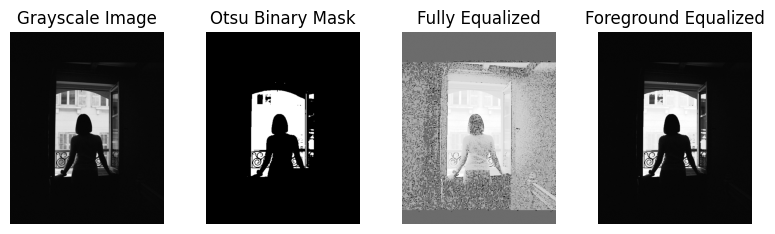

True

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


#Load image
img = cv.imread("/content/input_figure3.jpg")

#Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


# Otsu Threshold
ret, mask = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

print("Otsu Threshold Value:", ret)


# Histogram Equalization on Foreground

# Apply histogram equalization to entire image first
equalized = cv.equalizeHist(gray)

# Create result image (copy original)
result = gray.copy()

# Apply equalization only where mask = foreground
result[mask == 255] = equalized[mask == 255]


# -------- Display --------

plt.figure(figsize=(10,2.5))

titles = ["Grayscale Image", "Otsu Binary Mask", "Fully Equalized", "Foreground Equalized"]
images = [gray, mask, equalized, result]

for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=1)  # smaller font
    plt.axis("off")

# Reduce spacing between images
plt.subplots_adjust(wspace=0.05, hspace=0)

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(mask, cmap='gray')
plt.title("Otsu Binary Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(equalized, cmap='gray')
plt.title("Fully Equalized")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(result, cmap='gray')
plt.title("Foreground Equalized")
plt.axis("off")

plt.show()

plt.tight_layout()
plt.savefig("q4_combined.png", dpi=300, bbox_inches='tight')
plt.close()

# -------- Save Outputs --------

cv.imwrite("q4_mask.png", mask)
cv.imwrite("q4_equalized_foreground.png", result)